# Metric Anomaly Alerter

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/analytics-engineering-bi/metric-alerting/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=analytics-engineering-bi/metric-alerting/demo.ipynb)

> We notice metric drops late. This watches a metric and fires the day it moves — with three independent detectors.

A revenue drop on Monday that someone spots on Thursday is three days of damage. The fix isn't one
clever detector - it's a few *simple* ones that each catch a different failure shape: a hard floor
breach, a statistical outlier, and a sharp day-over-day move.

**What this notebook covers**
1. A metric time series with a real drop and spike planted in it
2. Three detectors: static threshold, rolling z-score, day-over-day trend
3. Why the z-score baseline must exclude the current point
4. Alerts with severity
5. The metric with anomalies flagged, visualized


## Step 1 - A metric with something to find

30 days of daily active users: stable, then a sudden **drop** (an incident) and later a **spike**
(bot traffic?). A good alerter should catch both without drowning us in noise on the stable days.

In [1]:
from alerting import detect_anomalies, summarize, sample_series, SAMPLE_CONFIG

series = sample_series()
print(series.head(10).to_string())
print("...")
print("Planted drop around day 19, spike around day 26.")


2026-06-01    1000.0
2026-06-02    1007.0
2026-06-03     993.0
2026-06-04     978.0
2026-06-05     989.0
2026-06-06     975.0
2026-06-07    1002.0
2026-06-08    1034.0
2026-06-09     988.0
2026-06-10     984.0
...
Planted drop around day 19, spike around day 26.


## Step 2 - Three detectors, one pass

- **threshold** — value outside a hard floor/ceiling (business SLA).
- **z-score** — value far from its recent rolling baseline (statistical outlier).
- **trend** — sharp day-over-day % move (sudden change even if still in range).

Each is cheap and explainable; together they cover far more than any one alone.

In [2]:
alerts = detect_anomalies(series, SAMPLE_CONFIG)
print("Summary:", summarize(alerts), "\n")
for a in alerts:
    print(f"{a.date}  [{a.severity:<8}] {a.kind:<9} {a.message}")


Summary: {'total': 10, 'by_severity': {'critical': 5, 'warning': 5, 'info': 0}, 'by_kind': {'zscore': 3, 'threshold': 3, 'trend': 4}} 

2026-06-08  [warning ] zscore    daily_active_users = 1034 is +3.7σ from 7-pt baseline (992)
2026-06-19  [critical] threshold daily_active_users = 640 below floor 800
2026-06-19  [critical] zscore    daily_active_users = 640 is -21.2σ from 7-pt baseline (994)
2026-06-19  [warning ] trend     daily_active_users moved -35% vs prior point (989 → 640)
2026-06-20  [critical] threshold daily_active_users = 700 below floor 800
2026-06-21  [warning ] trend     daily_active_users moved +36% vs prior point (700 → 954)
2026-06-26  [critical] zscore    daily_active_users = 1480 is +4.0σ from 7-pt baseline (895)
2026-06-26  [critical] trend     daily_active_users moved +47% vs prior point (1004 → 1480)
2026-06-26  [warning ] threshold daily_active_users = 1480 above ceiling 1300
2026-06-27  [warning ] trend     daily_active_users moved -37% vs prior point (1480 → 9

## Step 3 - The subtle bug: a point in its own baseline

If the rolling mean/std *includes* the current point, a single outlier hides inside the very
statistics meant to catch it - a 640 drop only reads as -2.4σ. Excluding the current point (baseline
= prior window only) makes the same drop read as **-21σ**. Same data, honest detector.

In [3]:
vals = series.astype(float)
drop_i = 18  # the planted drop

# WRONG: window includes the current point
incl_mean = vals.rolling(7, min_periods=7).mean().iloc[drop_i]
incl_std = vals.rolling(7, min_periods=7).std(ddof=0).iloc[drop_i]
z_incl = (vals.iloc[drop_i] - incl_mean) / incl_std

# RIGHT: baseline is the prior window only
prior = vals.shift(1)
excl_mean = prior.rolling(7, min_periods=7).mean().iloc[drop_i]
excl_std = prior.rolling(7, min_periods=7).std(ddof=0).iloc[drop_i]
z_excl = (vals.iloc[drop_i] - excl_mean) / excl_std

print(f"Drop value: {vals.iloc[drop_i]:.0f}")
print(f"  z including current point : {z_incl:+.1f}σ  (would MISS at 2.5σ)")
print(f"  z excluding current point : {z_excl:+.1f}σ  (clearly caught)")


Drop value: 640
  z including current point : -2.4σ  (would MISS at 2.5σ)
  z excluding current point : -21.2σ  (clearly caught)


## Step 4 - Visualize the metric with anomalies flagged

The whole point is a glanceable view: the line, the SLA bands, and colored dots where detectors
fired. Red = critical, orange = warning.

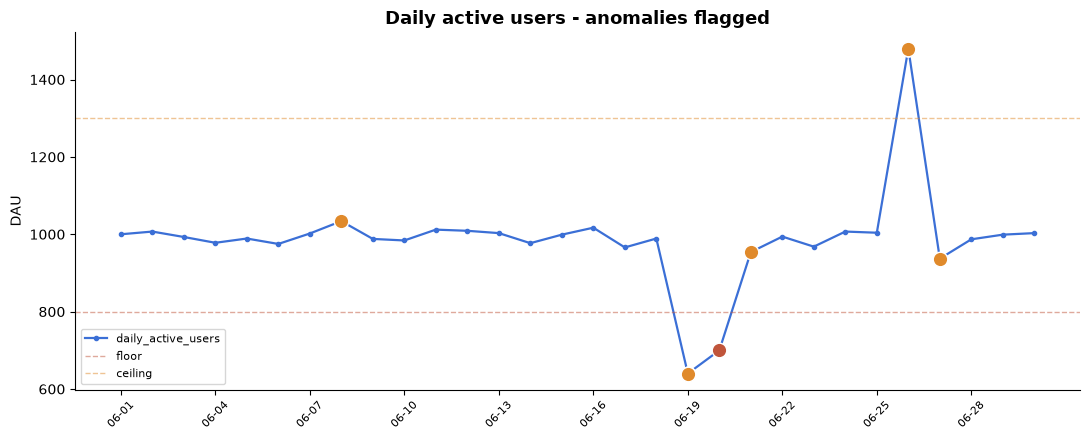

In [4]:
import matplotlib.pyplot as plt

sev_color = {"critical": "#c0553b", "warning": "#e08a2b", "info": "#3b6fd6"}
dates = list(series.index)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(range(len(series)), series.values, color="#3b6fd6", lw=1.6, marker="o", ms=3, label="daily_active_users")
ax.axhline(SAMPLE_CONFIG.min_value, color="#c0553b", ls="--", lw=1, alpha=0.5, label="floor")
ax.axhline(SAMPLE_CONFIG.max_value, color="#e08a2b", ls="--", lw=1, alpha=0.5, label="ceiling")
for a in alerts:
    i = dates.index(a.date)
    ax.scatter([i], [a.value], color=sev_color[a.severity], s=110, zorder=5, edgecolors="white")
ax.set_title("Daily active users - anomalies flagged", fontsize=13, weight="bold")
ax.set_xticks(range(0, len(series), 3))
ax.set_xticklabels([dates[i][5:] for i in range(0, len(series), 3)], rotation=45, fontsize=8)
ax.set_ylabel("DAU")
ax.legend(loc="lower left", fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("anomalies.png", dpi=120, bbox_inches="tight")
plt.show()


## Summary

| Detector | Catches | Example here |
|----------|---------|--------------|
| threshold | SLA breach | DAU 640 < floor 800 |
| z-score | statistical outlier | −21σ drop, +4σ spike |
| trend | sudden move | −35% day-over-day |

Three simple checks, each explainable, beat one opaque model for on-call trust. The drop that used
to surface on Thursday now pages on the day it happens.

**Extend it:** run this on a schedule against your warehouse, route criticals to PagerDuty/Slack,
and add seasonality (day-of-week baselines) so Monday isn't always "anomalously" low.

In [5]:
# --- Try your own metric ---
# import pandas as pd
# from alerting import MetricConfig
# s = pd.Series([...], index=[...])   # your daily metric
# cfg = MetricConfig(name="my_metric", min_value=..., trend_pct=0.15, direction="drop")
# for a in detect_anomalies(s, cfg):
#     print(a.date, a.severity, a.message)


---

Part of [**phoebe-the-builder**](https://github.com/phoebefu6/phoebe-the-builder) - Day 104,
Month 11: Analytics Engineering & BI.

**Run the app:** `pip install -r requirements.txt && streamlit run app.py`